# Deep NLP Project - QA Model V3

Version from-scratch avec améliorations: tokenizer robuste, tête no-answer, décodage span conjoint, early stopping, device Apple MPS.


## 1) Imports et Device


In [20]:
import os
import re
import json
import math
import random
import string
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


Device: mps


## 2) Paramètres


In [2]:
data_path = "data/"
train_path = os.path.join(data_path, "train-v2.0.json")
dev_path = os.path.join(data_path, "dev-v2.0.json")

MAX_CONTEXT_LEN = 220
MAX_QUESTION_LEN = 40
MIN_FREQ = 2

BATCH_SIZE = 32
NUM_EPOCHS = 10
EMBED_DIM = 200
HIDDEN_SIZE = 128
LR = 2e-3
WEIGHT_DECAY = 1e-2
CLIP_NORM = 1.0
PATIENCE = 3

NO_ANSWER_WEIGHT = 0.7
MAX_ANSWER_LEN = 30
NO_ANSWER_THRESHOLD = 0.5

TRAIN_SUBSET = None   # ex: 30000
DEV_SUBSET = 3000     # None = full dev


## 3) Tokenization et Chargement SQuAD v2


In [3]:
TOKEN_PATTERN = re.compile(r"\w+|[^\w\s]")

def tokenize_advanced(text):
    return TOKEN_PATTERN.findall(text.lower())

def char_to_token_span(context, context_tokens, answer_start, answer_text):
    lowered = context.lower()
    offsets = []
    cursor = 0
    for tok in context_tokens:
        idx = lowered.find(tok, cursor)
        if idx == -1:
            idx = lowered.find(tok)
            if idx == -1:
                return None, None
        offsets.append((idx, idx + len(tok)))
        cursor = idx + len(tok)

    ans_start = answer_start
    ans_end = answer_start + len(answer_text)
    s_tok = e_tok = None
    for i, (s, e) in enumerate(offsets):
        if s <= ans_start < e:
            s_tok = i
        if s < ans_end <= e:
            e_tok = i
            break
    return s_tok, e_tok

def load_squad_v2(path, max_examples=None):
    with open(path, "r", encoding="utf-8") as f:
        squad = json.load(f)

    examples = []
    for article in squad["data"]:
        for paragraph in article["paragraphs"]:
            context = paragraph["context"]
            context_tokens = tokenize_advanced(context)
            for qa in paragraph["qas"]:
                question_tokens = tokenize_advanced(qa["question"])
                is_impossible = qa.get("is_impossible", False)

                if is_impossible:
                    examples.append({
                        "context_tokens": context_tokens,
                        "question_tokens": question_tokens,
                        "start": 0,
                        "end": 0,
                        "has_answer": 0,
                        "raw_answer": "",
                    })
                else:
                    answers = qa.get("answers", [])
                    if not answers:
                        continue
                    ans = answers[0]
                    s_tok, e_tok = char_to_token_span(context, context_tokens, ans["answer_start"], ans["text"].lower())
                    if s_tok is None or e_tok is None:
                        continue
                    examples.append({
                        "context_tokens": context_tokens,
                        "question_tokens": question_tokens,
                        "start": s_tok + 1,  # 0 réservé à <CLS>
                        "end": e_tok + 1,
                        "has_answer": 1,
                        "raw_answer": ans["text"],
                    })

                if max_examples is not None and len(examples) >= max_examples:
                    return examples
    return examples

train_examples = load_squad_v2(train_path, TRAIN_SUBSET)
dev_examples = load_squad_v2(dev_path, DEV_SUBSET)
print("Train:", len(train_examples), "| Dev:", len(dev_examples))


Train: 130309 | Dev: 3000


## 4) Vocabulaire et Encodage


In [4]:
def build_vocab(examples, min_freq=2):
    counter = Counter()
    for ex in examples:
        counter.update(ex["context_tokens"])
        counter.update(ex["question_tokens"])

    vocab = {"<PAD>": 0, "<UNK>": 1, "<CLS>": 2}
    for tok, freq in counter.items():
        if freq >= min_freq and tok not in vocab:
            vocab[tok] = len(vocab)
    return vocab

vocab = build_vocab(train_examples, MIN_FREQ)
VOCAB_SIZE = len(vocab)
print("Vocab size:", VOCAB_SIZE)

def encode(tokens, vocab_obj, max_len, add_cls=False):
    if add_cls:
        tokens = ["<CLS>"] + tokens
    ids = [vocab_obj.get(t, vocab_obj["<UNK>"]) for t in tokens][:max_len]
    return ids + [vocab_obj["<PAD>"]] * (max_len - len(ids))

def prepare_data(examples, vocab_obj):
    Xc, Xq, ys, ye, ya = [], [], [], [], []
    for ex in examples:
        if ex["start"] >= MAX_CONTEXT_LEN or ex["end"] >= MAX_CONTEXT_LEN:
            continue
        Xc.append(encode(ex["context_tokens"], vocab_obj, MAX_CONTEXT_LEN, add_cls=True))
        Xq.append(encode(ex["question_tokens"], vocab_obj, MAX_QUESTION_LEN, add_cls=False))
        ys.append(ex["start"])
        ye.append(ex["end"])
        ya.append(ex["has_answer"])
    return np.array(Xc), np.array(Xq), np.array(ys), np.array(ye), np.array(ya)

Xc_train, Xq_train, ys_train, ye_train, ya_train = prepare_data(train_examples, vocab)
Xc_dev, Xq_dev, ys_dev, ye_dev, ya_dev = prepare_data(dev_examples, vocab)
print("Train tensors:", Xc_train.shape, Xq_train.shape)
print("Dev tensors:", Xc_dev.shape, Xq_dev.shape)


Vocab size: 80404
Train tensors: (129302, 220) (129302, 40)
Dev tensors: (2993, 220) (2993, 40)


## 5) DataLoaders


In [5]:
train_ds = TensorDataset(
    torch.LongTensor(Xc_train),
    torch.LongTensor(Xq_train),
    torch.LongTensor(ys_train),
    torch.LongTensor(ye_train),
    torch.FloatTensor(ya_train),
)

dev_ds = TensorDataset(
    torch.LongTensor(Xc_dev),
    torch.LongTensor(Xq_dev),
    torch.LongTensor(ys_dev),
    torch.LongTensor(ye_dev),
    torch.FloatTensor(ya_dev),
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
dev_loader = DataLoader(dev_ds, batch_size=BATCH_SIZE, shuffle=False)
print("Batches train/dev:", len(train_loader), len(dev_loader))


Batches train/dev: 4041 94


## 6) Modèle V3


In [ ]:
from models import QAModelV3

model_v3 = QAModelV3(VOCAB_SIZE, EMBED_DIM, HIDDEN_SIZE).to(device)
print(model_v3.__class__.__name__)



## 7) Entraînement (Early Stopping)


In [7]:
optimizer = optim.AdamW(model_v3.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
ce_loss = nn.CrossEntropyLoss()
bce_loss = nn.BCEWithLogitsLoss()

def run_epoch(model, loader, optimizer_obj=None):
    train_mode = optimizer_obj is not None
    model.train() if train_mode else model.eval()
    total = 0.0
    for ctx, qst, y_s, y_e, y_has in loader:
        ctx, qst = ctx.to(device), qst.to(device)
        y_s, y_e, y_has = y_s.to(device), y_e.to(device), y_has.to(device)
        with torch.set_grad_enabled(train_mode):
            s_logits, e_logits, na_logit = model(ctx, qst)
            loss_span = ce_loss(s_logits, y_s) + ce_loss(e_logits, y_e)
            loss_na = bce_loss(na_logit, 1.0 - y_has)
            loss = loss_span + NO_ANSWER_WEIGHT * loss_na
            if train_mode:
                optimizer_obj.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
                optimizer_obj.step()
        total += loss.item()
    return total / max(len(loader), 1)

best_val = float('inf')
pat_left = PATIENCE
for epoch in range(1, NUM_EPOCHS + 1):
    tr = run_epoch(model_v3, train_loader, optimizer)
    va = run_epoch(model_v3, dev_loader, None)
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | train={tr:.4f} | dev={va:.4f}")
    if va < best_val:
        best_val = va
        pat_left = PATIENCE
        torch.save(model_v3.state_dict(), 'bidaf_model_v3_best.pt')
        print("  -> best checkpoint saved")
    else:
        pat_left -= 1
        print("  -> no improvement, patience:", pat_left)
        if pat_left == 0:
            print("Early stopping")
            break


Epoch 01/10 | train=6.2211 | dev=5.1284
  -> best checkpoint saved
Epoch 02/10 | train=5.2570 | dev=5.0773
  -> best checkpoint saved
Epoch 03/10 | train=4.7590 | dev=5.5967
  -> no improvement, patience: 2
Epoch 04/10 | train=4.3920 | dev=5.6507
  -> no improvement, patience: 1
Epoch 05/10 | train=4.0921 | dev=6.2704
  -> no improvement, patience: 0
Early stopping


## 8) Évaluation EM/F1 + Décodage Conjoint + Post-traitement


In [8]:
def normalize_answer(s):
    s = s.lower()
    s = ''.join(ch for ch in s if ch not in set(string.punctuation))
    s = re.sub(r'\b(a|an|the)\b', ' ', s)
    return ' '.join(s.split())

def compute_em(pred, truth):
    return int(normalize_answer(pred) == normalize_answer(truth))

def compute_f1(pred, truth):
    p = normalize_answer(pred).split()
    t = normalize_answer(truth).split()
    if not p and not t:
        return 1.0
    if not p or not t:
        return 0.0
    common = Counter(p) & Counter(t)
    n = sum(common.values())
    if n == 0:
        return 0.0
    prec, rec = n / len(p), n / len(t)
    return 2 * prec * rec / (prec + rec)

def clean_prediction(prediction):
    prediction = re.sub(r"^[\s\(\)\[\],;:\.""]+", "", prediction)
    prediction = re.sub(r"[\s\(\)\[\],;:\.""]+$", "", prediction)
    prediction = re.sub(r'\s+', ' ', prediction).strip()
    return prediction

@torch.no_grad()
def decode_best_span(start_logits, end_logits, max_answer_len=30):
    best_score = -1e30
    best_s, best_e = 0, 0
    L = start_logits.size(0)
    for s in range(L):
        e_max = min(L - 1, s + max_answer_len - 1)
        e_rel = torch.argmax(end_logits[s:e_max+1]).item()
        e = s + e_rel
        score = start_logits[s].item() + end_logits[e].item()
        if score > best_score:
            best_score = score
            best_s, best_e = s, e
    return best_s, best_e

@torch.no_grad()
def predict_answer_v3(model, context_tokens, question_tokens, vocab_obj, no_answer_threshold=0.5):
    model.eval()
    ctx = torch.LongTensor([encode(context_tokens, vocab_obj, MAX_CONTEXT_LEN, add_cls=True)]).to(device)
    qst = torch.LongTensor([encode(question_tokens, vocab_obj, MAX_QUESTION_LEN, add_cls=False)]).to(device)
    s_logits, e_logits, na_logit = model(ctx, qst)
    s_logits, e_logits = s_logits[0], e_logits[0]

    p_no = torch.sigmoid(na_logit[0]).item()
    if p_no >= no_answer_threshold:
        return '', 0, 0, p_no

    s_idx, e_idx = decode_best_span(s_logits, e_logits, MAX_ANSWER_LEN)
    if s_idx == 0 or e_idx == 0:
        return '', s_idx, e_idx, p_no

    s_txt = s_idx - 1
    e_txt = min(e_idx - 1, len(context_tokens)-1)
    if e_txt < s_txt:
        return '', s_idx, e_idx, p_no

    pred = ' '.join(context_tokens[s_txt:e_txt+1])
    return clean_prediction(pred), s_idx, e_idx, p_no

if os.path.exists('bidaf_model_v3_best.pt'):
    model_v3.load_state_dict(torch.load('bidaf_model_v3_best.pt', map_location=device))

em_total = 0
f1_total = 0.0
n = 0
for ex in dev_examples:
    if ex['start'] >= MAX_CONTEXT_LEN or ex['end'] >= MAX_CONTEXT_LEN:
        continue
    pred, _, _, _ = predict_answer_v3(model_v3, ex['context_tokens'], ex['question_tokens'], vocab, NO_ANSWER_THRESHOLD)
    truth = ex['raw_answer']
    em_total += compute_em(pred, truth)
    f1_total += compute_f1(pred, truth)
    n += 1

print('='*90)
print('MODEL V3 - FINAL EVAL')
print('N =', n)
print(f'EM = {100*em_total/max(n,1):.2f}%')
print(f'F1 = {100*f1_total/max(n,1):.2f}%')
print('='*90)


MODEL V3 - FINAL EVAL
N = 2993
EM = 37.19%
F1 = 39.21%


## 9) Exemples Qualitatifs


In [11]:
for i in range(min(5, len(dev_examples))):
    ex = dev_examples[i]
    pred, s, e, p_no = predict_answer_v3(model_v3, ex['context_tokens'], ex['question_tokens'], vocab, NO_ANSWER_THRESHOLD)
    print(f"Exemple {i+1}")
    print("Q:", ' '.join(ex['question_tokens']))
    print("True:", ex['raw_answer'] if ex['raw_answer'] else '[NO_ANSWER]')
    print("Pred:", pred if pred else '[NO_ANSWER]')
    print(f"p_no_answer={p_no:.3f}, span=({s},{e})")
    print('-'*90)


Exemple 1
Q: in what country is normandy located ?
True: France
Pred: france
p_no_answer=0.050, span=(35,35)
------------------------------------------------------------------------------------------
Exemple 2
Q: when were the normans in normandy ?
True: 10th and 11th centuries
Pred: 10th
p_no_answer=0.070, span=(22,22)
------------------------------------------------------------------------------------------
Exemple 3
Q: from which countries did the norse originate ?
True: Denmark, Iceland and Norway
Pred: france
p_no_answer=0.111, span=(35,35)
------------------------------------------------------------------------------------------
Exemple 4
Q: who was the norse leader ?
True: Rollo
Pred: charles iii of west francia
p_no_answer=0.226, span=(74,78)
------------------------------------------------------------------------------------------
Exemple 5
Q: what century did the normans first gain their separate identity ?
True: 10th century
Pred: 10th
p_no_answer=0.049, span=(128,128)
-----

## 10) Sauvegarde


In [12]:
torch.save(model_v3.state_dict(), 'bidaf_model_v3_last.pt')
print('Saved: bidaf_model_v3_last.pt')
if os.path.exists('bidaf_model_v3_best.pt'):
    print('Best: bidaf_model_v3_best.pt')


Saved: bidaf_model_v3_last.pt
Best: bidaf_model_v3_best.pt


## 11) Modèle V4 : Calibration et Décodage Optimisé

Cette partie construit **V4** à partir de V3 sans ré-entraînement lourd:
- calibration du seuil `no-answer` (0.10)
- décodage de span `top-k` avec pénalité de longueur
- mêmes poids réseau, meilleure stratégie d'inférence


In [15]:
# Hyperparamètres d'inférence V4 (issus du notebook d'évaluation)
V4_NO_ANSWER_THRESHOLD = 0.10
V4_TOPK = 20
V4_MAX_ANSWER_LEN = 15
V4_LENGTH_PENALTY = 0.02

print('Configuration V4 chargée:')
print(f'  threshold no-answer = {V4_NO_ANSWER_THRESHOLD}')
print(f'  top-k              = {V4_TOPK}')
print(f'  max answer len     = {V4_MAX_ANSWER_LEN}')
print(f'  length penalty     = {V4_LENGTH_PENALTY}')


Configuration V4 chargée:
  threshold no-answer = 0.1
  top-k              = 20
  max answer len     = 15
  length penalty     = 0.02


## 12) Fonctions d'Inférence V4

Décodage amélioré:
- recherche conjointe `(start, end)` sur les meilleurs logits
- contrainte de longueur max
- pénalité des spans trop longs
- décision no-answer avec seuil calibré


In [16]:
@torch.no_grad()
def decode_best_span_topk_v4(start_logits, end_logits, max_answer_len=15, topk=20, length_penalty=0.02):
    """Sélectionne le meilleur span en combinant top-k start/end + pénalité de longueur."""
    L = start_logits.size(0)
    k = min(topk, L)

    s_vals, s_idx = torch.topk(start_logits, k=k)
    e_vals, e_idx = torch.topk(end_logits, k=k)

    best_score = -1e30
    best_s, best_e = 0, 0

    for i in range(k):
        s = s_idx[i].item()
        for j in range(k):
            e = e_idx[j].item()
            if e < s:
                continue

            span_len = e - s + 1
            if span_len > max_answer_len:
                continue

            score = s_vals[i].item() + e_vals[j].item() - length_penalty * span_len
            if score > best_score:
                best_score = score
                best_s, best_e = s, e

    return best_s, best_e


@torch.no_grad()
def predict_answer_v4(model, context_tokens, question_tokens, vocab, no_answer_threshold=0.10,
                      topk=20, max_answer_len=15, length_penalty=0.02):
    model.eval()

    ctx_ids = torch.LongTensor([encode(context_tokens, vocab, MAX_CONTEXT_LEN, add_cls=True)]).to(device)
    qst_ids = torch.LongTensor([encode(question_tokens, vocab, MAX_QUESTION_LEN, add_cls=False)]).to(device)

    s_logits, e_logits, na_logit = model(ctx_ids, qst_ids)
    s_logits = s_logits[0]
    e_logits = e_logits[0]

    p_no_answer = torch.sigmoid(na_logit[0]).item()
    if p_no_answer >= no_answer_threshold:
        return '', 0, 0, p_no_answer

    s_idx, e_idx = decode_best_span_topk_v4(
        s_logits,
        e_logits,
        max_answer_len=max_answer_len,
        topk=topk,
        length_penalty=length_penalty,
    )

    if s_idx == 0 or e_idx == 0:
        return '', s_idx, e_idx, p_no_answer

    s_txt = s_idx - 1
    e_txt = min(e_idx - 1, len(context_tokens) - 1)
    if e_txt < s_txt:
        return '', s_idx, e_idx, p_no_answer

    pred = ' '.join(context_tokens[s_txt:e_txt+1])
    pred = clean_prediction(pred)
    return pred, s_idx, e_idx, p_no_answer


## 13) Évaluation Comparative V3 vs V4

Cette section compare directement:
- **V3 baseline**: `threshold=NO_ANSWER_THRESHOLD` + décodage greedy
- **V4 optimisé**: `threshold=0.10` + décodage top-k pénalisé


In [17]:
def evaluate_with_predict_fn(examples, predict_fn):
    em_total = 0
    f1_total = 0.0
    n = 0

    for ex in examples:
        if ex['start'] >= MAX_CONTEXT_LEN or ex['end'] >= MAX_CONTEXT_LEN:
            continue

        pred, _, _, _ = predict_fn(model_v3, ex['context_tokens'], ex['question_tokens'], vocab)
        truth = ex['raw_answer']

        em_total += compute_em(pred, truth)
        f1_total += compute_f1(pred, truth)
        n += 1

    return {
        'n_eval': n,
        'em': 100.0 * em_total / max(n, 1),
        'f1': 100.0 * f1_total / max(n, 1),
    }


def _predict_v3_baseline(model, context_tokens, question_tokens, vocab):
    return predict_answer_v3(model, context_tokens, question_tokens, vocab, no_answer_threshold=NO_ANSWER_THRESHOLD)


def _predict_v4_optimized(model, context_tokens, question_tokens, vocab):
    return predict_answer_v4(
        model,
        context_tokens,
        question_tokens,
        vocab,
        no_answer_threshold=V4_NO_ANSWER_THRESHOLD,
        topk=V4_TOPK,
        max_answer_len=V4_MAX_ANSWER_LEN,
        length_penalty=V4_LENGTH_PENALTY,
    )


v3_metrics = evaluate_with_predict_fn(dev_examples, _predict_v3_baseline)
v4_metrics = evaluate_with_predict_fn(dev_examples, _predict_v4_optimized)

print('| Version | N évalués | EM (%) | F1 (%) |')
print('|---|---:|---:|---:|')
print(f"| V3 baseline | {v3_metrics['n_eval']} | {v3_metrics['em']:.2f} | {v3_metrics['f1']:.2f} |")
print(f"| V4 optimisé | {v4_metrics['n_eval']} | {v4_metrics['em']:.2f} | {v4_metrics['f1']:.2f} |")

print('\nDelta (V4 - V3):')
print(f"EM: {v4_metrics['em'] - v3_metrics['em']:+.2f} points")
print(f"F1: {v4_metrics['f1'] - v3_metrics['f1']:+.2f} points")



| Version | N évalués | EM (%) | F1 (%) |
|---|---:|---:|---:|
| V3 baseline | 2993 | 37.19 | 39.21 |
| V4 optimisé | 2993 | 48.71 | 49.08 |

Delta (V4 - V3):
EM: +11.53 points
F1: +9.87 points


## 14) Export V4 (Checkpoint + Config d'Inférence)

On sauvegarde un package V4 simple à réutiliser:
- `bidaf_model_v4_best.pt` (mêmes poids que V3 best)
- `bidaf_model_v4_config.json` (hyperparamètres d'inférence optimisés)


In [18]:
import json as _json

torch.save(model_v3.state_dict(), 'bidaf_model_v4_best.pt')

v4_config = {
    'checkpoint': 'bidaf_model_v4_best.pt',
    'no_answer_threshold': V4_NO_ANSWER_THRESHOLD,
    'topk': V4_TOPK,
    'max_answer_len': V4_MAX_ANSWER_LEN,
    'length_penalty': V4_LENGTH_PENALTY,
    'max_context_len': MAX_CONTEXT_LEN,
    'max_question_len': MAX_QUESTION_LEN,
}

with open('bidaf_model_v4_config.json', 'w', encoding='utf-8') as f:
    _json.dump(v4_config, f, ensure_ascii=False, indent=2)

print('Export terminé:')
print('- bidaf_model_v4_best.pt')
print('- bidaf_model_v4_config.json')


Export terminé:
- bidaf_model_v4_best.pt
- bidaf_model_v4_config.json


## 15) Modèle V5 : Architecture Renforcée

V5 conserve l'approche from-scratch mais augmente la capacité:
- deux couches de modeling pour les spans
- régularisation plus stable
- calibration orientée SQuAD v2 (no-answer plus pondéré)


In [31]:
import importlib
import models

importlib.reload(models)
from models import QAModelV5

In [32]:
# Hyperparamètres V5 (tu peux les ajuster)
V5_HIDDEN_SIZE = 192
V5_EMBED_DIM = 300
V5_NUM_EPOCHS = 12
V5_LR = 1.5e-3
V5_WEIGHT_DECAY = 1e-2
V5_NO_ANSWER_WEIGHT = 1.1
V5_PATIENCE = 3

model_v5 = QAModelV5(VOCAB_SIZE, V5_EMBED_DIM, V5_HIDDEN_SIZE).to(device)
print(model_v5.__class__.__name__)


QAModelV5


## 16) Entraînement V5 (Early Stopping sur F1 Dev)

On sauvegarde le meilleur checkpoint selon **F1 dev** (et non uniquement la loss).


In [33]:
optimizer_v5 = optim.AdamW(model_v5.parameters(), lr=V5_LR, weight_decay=V5_WEIGHT_DECAY)
ce_loss_v5 = nn.CrossEntropyLoss()
bce_loss_v5 = nn.BCEWithLogitsLoss()


def run_epoch_v5(model, loader, optimizer_obj=None):
    train_mode = optimizer_obj is not None
    model.train() if train_mode else model.eval()
    total_loss = 0.0

    for ctx, qst, y_s, y_e, y_has in loader:
        ctx = ctx.to(device)
        qst = qst.to(device)
        y_s = y_s.to(device)
        y_e = y_e.to(device)
        y_has = y_has.to(device)

        with torch.set_grad_enabled(train_mode):
            s_logits, e_logits, na_logit = model(ctx, qst)
            loss_span = ce_loss_v5(s_logits, y_s) + ce_loss_v5(e_logits, y_e)
            loss_no_answer = bce_loss_v5(na_logit, 1.0 - y_has)
            loss = loss_span + V5_NO_ANSWER_WEIGHT * loss_no_answer

            if train_mode:
                optimizer_obj.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
                optimizer_obj.step()

        total_loss += loss.item()

    return total_loss / max(len(loader), 1)


@torch.no_grad()
def evaluate_quick_f1_v5(model, examples, limit=1200):
    # Eval rapide pour le early stopping (utilise déjà la logique V4 optimisée).
    em_total = 0
    f1_total = 0.0
    n = 0
    for ex in examples[:limit]:
        if ex['start'] >= MAX_CONTEXT_LEN or ex['end'] >= MAX_CONTEXT_LEN:
            continue
        pred, _, _, _ = predict_answer_v4(
            model,
            ex['context_tokens'],
            ex['question_tokens'],
            vocab,
            no_answer_threshold=V4_NO_ANSWER_THRESHOLD,
            topk=V4_TOPK,
            max_answer_len=V4_MAX_ANSWER_LEN,
            length_penalty=V4_LENGTH_PENALTY,
        )
        truth = ex['raw_answer']
        em_total += compute_em(pred, truth)
        f1_total += compute_f1(pred, truth)
        n += 1

    return {
        'n_eval': n,
        'em': 100.0 * em_total / max(n, 1),
        'f1': 100.0 * f1_total / max(n, 1),
    }


best_v5_f1 = -1.0
best_v5_loss = float('inf')
pat_left = V5_PATIENCE

# Historique pour graphiques et reporting
v5_history = []
V5_RUN_NAME = globals().get('V5_RUN_NAME', 'v5_run_01')

for epoch in range(1, V5_NUM_EPOCHS + 1):
    tr_loss = run_epoch_v5(model_v5, train_loader, optimizer_v5)
    va_loss = run_epoch_v5(model_v5, dev_loader, None)
    quick = evaluate_quick_f1_v5(model_v5, dev_examples, limit=1200)

    v5_history.append({
        'epoch': epoch,
        'train_loss': float(tr_loss),
        'val_loss': float(va_loss),
        'val_em': float(quick['em']),
        'val_f1': float(quick['f1']),
    })

    print(f"Epoch {epoch:02d}/{V5_NUM_EPOCHS} | train={tr_loss:.4f} | dev_loss={va_loss:.4f} | dev_F1~={quick['f1']:.2f}")

    improved = quick['f1'] > best_v5_f1
    if improved:
        best_v5_f1 = quick['f1']
        best_v5_loss = va_loss
        pat_left = V5_PATIENCE
        torch.save(model_v5.state_dict(), 'bidaf_model_v5_best.pt')
        print('  -> Nouveau best V5 sauvegardé (selon F1 dev).')
    else:
        pat_left -= 1
        print(f'  -> Pas d amélioration F1. Patience restante: {pat_left}')
        if pat_left == 0:
            print('Early stopping V5 déclenché.')
            break

print('Best V5 quick F1:', best_v5_f1)


Epoch 01/12 | train=6.5691 | dev_loss=5.3606 | dev_F1~=49.87
  -> Nouveau best V5 sauvegardé (selon F1 dev).
Epoch 02/12 | train=5.6318 | dev_loss=5.3916 | dev_F1~=50.00
  -> Nouveau best V5 sauvegardé (selon F1 dev).
Epoch 03/12 | train=5.1487 | dev_loss=5.7597 | dev_F1~=43.43
  -> Pas d amélioration F1. Patience restante: 2
Epoch 04/12 | train=4.8292 | dev_loss=6.1183 | dev_F1~=43.85
  -> Pas d amélioration F1. Patience restante: 1
Epoch 05/12 | train=4.5872 | dev_loss=5.8527 | dev_F1~=44.94
  -> Pas d amélioration F1. Patience restante: 0
Early stopping V5 déclenché.
Best V5 quick F1: 49.997219905476776


## 17) Évaluation Finale V5 (Décodage Optimisé)

Évalue V5 avec la stratégie d'inférence optimisée (threshold + top-k).


In [34]:
if os.path.exists('bidaf_model_v5_best.pt'):
    model_v5.load_state_dict(torch.load('bidaf_model_v5_best.pt', map_location=device))


def evaluate_model_v5_full(examples):
    em_total = 0
    f1_total = 0.0
    n = 0

    for ex in examples:
        if ex['start'] >= MAX_CONTEXT_LEN or ex['end'] >= MAX_CONTEXT_LEN:
            continue

        pred, _, _, _ = predict_answer_v4(
            model_v5,
            ex['context_tokens'],
            ex['question_tokens'],
            vocab,
            no_answer_threshold=V4_NO_ANSWER_THRESHOLD,
            topk=V4_TOPK,
            max_answer_len=V4_MAX_ANSWER_LEN,
            length_penalty=V4_LENGTH_PENALTY,
        )
        truth = ex['raw_answer']
        em_total += compute_em(pred, truth)
        f1_total += compute_f1(pred, truth)
        n += 1

    return {
        'n_eval': n,
        'em': 100.0 * em_total / max(n, 1),
        'f1': 100.0 * f1_total / max(n, 1),
    }

v5_metrics = evaluate_model_v5_full(dev_examples)
print('| Version | N évalués | EM (%) | F1 (%) |')
print('|---|---:|---:|---:|')
print(f"| V5 optimisé | {v5_metrics['n_eval']} | {v5_metrics['em']:.2f} | {v5_metrics['f1']:.2f} |")


| Version | N évalués | EM (%) | F1 (%) |
|---|---:|---:|---:|
| V5 optimisé | 2993 | 48.58 | 48.78 |


## 18) Export V5 (Checkpoint + Config)

On exporte le checkpoint et les paramètres d'inférence pour réutiliser V5 facilement.


In [35]:
import json as _json

torch.save(model_v5.state_dict(), 'bidaf_model_v5_last.pt')

v5_config = {
    'checkpoint': 'bidaf_model_v5_best.pt',
    'no_answer_threshold': V4_NO_ANSWER_THRESHOLD,
    'topk': V4_TOPK,
    'max_answer_len': V4_MAX_ANSWER_LEN,
    'length_penalty': V4_LENGTH_PENALTY,
    'max_context_len': MAX_CONTEXT_LEN,
    'max_question_len': MAX_QUESTION_LEN,
    'embed_dim': V5_EMBED_DIM,
    'hidden_size': V5_HIDDEN_SIZE,
}

with open('bidaf_model_v5_config.json', 'w', encoding='utf-8') as f:
    _json.dump(v5_config, f, ensure_ascii=False, indent=2)

print('Export V5 terminé:')
print('- bidaf_model_v5_best.pt')
print('- bidaf_model_v5_last.pt')
print('- bidaf_model_v5_config.json')


Export V5 terminé:
- bidaf_model_v5_best.pt
- bidaf_model_v5_last.pt
- bidaf_model_v5_config.json


## 19) V5 Training Curves for Slides

This section exports the training history and plots slide-ready curves:
- train/validation loss per epoch
- validation EM/F1 per epoch
- optional comparison across multiple V5 runs


In [36]:
import csv
from pathlib import Path

# Sauvegarde historique V5 en CSV
assert 'v5_history' in globals() and len(v5_history) > 0, 'Run V5 training cell first to populate v5_history.'

logs_dir = Path('logs')
logs_dir.mkdir(exist_ok=True)

run_name = globals().get('V5_RUN_NAME', 'v5_run_01')
log_path = logs_dir / f'{run_name}.csv'

fieldnames = ['epoch', 'train_loss', 'val_loss', 'val_em', 'val_f1']
with log_path.open('w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    for row in v5_history:
        writer.writerow(row)

print('Saved training log:', log_path)
print('Rows:', len(v5_history))


Saved training log: logs/v5_run_01.csv
Rows: 5


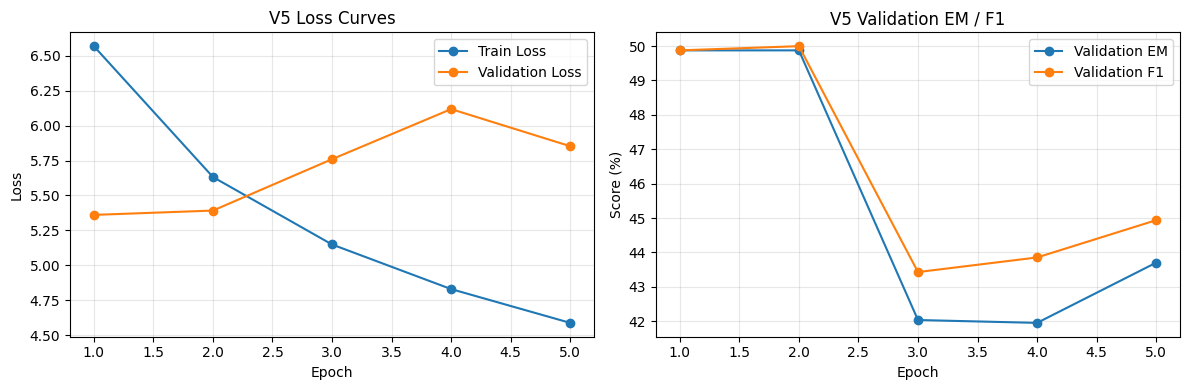

In [39]:
import matplotlib.pyplot as plt

assert 'v5_history' in globals() and len(v5_history) > 0, 'Run V5 training first.'

epochs = [r['epoch'] for r in v5_history]
train_loss = [r['train_loss'] for r in v5_history]
val_loss = [r['val_loss'] for r in v5_history]
val_em = [r['val_em'] for r in v5_history]
val_f1 = [r['val_f1'] for r in v5_history]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, marker='o', label='Train Loss')
plt.plot(epochs, val_loss, marker='o', label='Validation Loss')
plt.title('V5 Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, val_em, marker='o', label='Validation EM')
plt.plot(epochs, val_f1, marker='o', label='Validation F1')
plt.title('V5 Validation EM / F1')
plt.xlabel('Epoch')
plt.ylabel('Score (%)')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


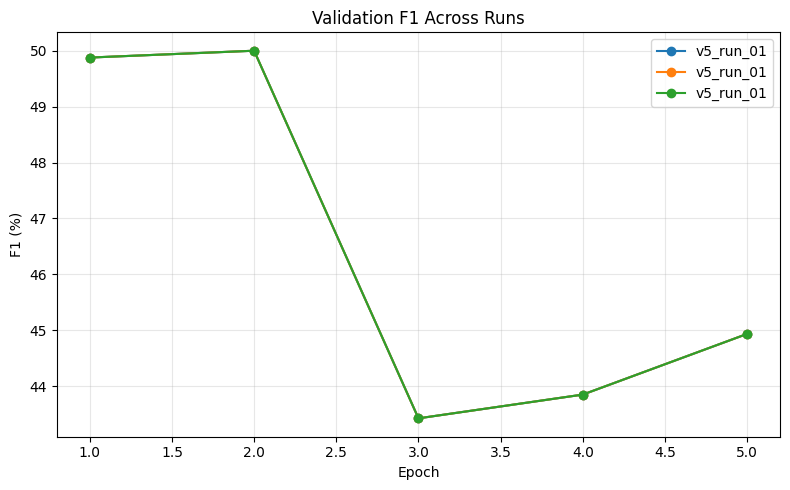

In [41]:
# Optional: compare multiple V5 runs saved in logs/*.csv
import csv
from pathlib import Path
import matplotlib.pyplot as plt

logs_dir = Path('logs')
csv_files = sorted(logs_dir.glob('v5_*.csv')) + sorted(logs_dir.glob('v5_run*.csv')) + sorted(logs_dir.glob('*.csv'))

if len(csv_files) == 0:
    print('No CSV logs found in logs/. Run the export cell first.')
else:
    plt.figure(figsize=(8, 5))
    for p in csv_files:
        rows = []
        with p.open('r', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            for r in reader:
                rows.append(r)
        if not rows:
            continue
        x = [int(r['epoch']) for r in rows]
        y = [float(r['val_f1']) for r in rows]
        plt.plot(x, y, marker='o', label=p.stem)

    plt.title('Validation F1 Across Runs')
    plt.xlabel('Epoch')
    plt.ylabel('F1 (%)')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
